# GWR sobre la Predicción Real de Altiplano/No-Altiplano (v2, corregido)

## Por qué existe este notebook

**Corrección pedida por el usuario:** `13_MGWR_altiplanos_v2.ipynb` ajusta GWR/MGWR sobre
`Altitud_X` (continua) usando únicamente los 491 polígonos de altiplano ya delimitados —
igual que en `10_SAR_altiplanos_v2.ipynb`, **nunca evalúa si el modelo distingue Altiplano
de No-Altiplano**. Aquí se corrige eso: se evalúa GWR sobre la **clasificación binaria
real** (Altiplano=1 / No-Altiplano=0) usando una muestra de la **capa de celdas**.

**Este notebook NO modifica `13_MGWR_altiplanos_v2.ipynb`** — queda intacto. Este es un
notebook nuevo y separado con un objetivo distinto.

## Dos cambios de método respecto al notebook original

1. **Familia del modelo:** `mgwr.gwr.GWR` soporta nativamente `family=Binomial()` (regresión
   logística local genuina, no una aproximación) — se usa directamente, sin necesidad de
   inventar un sustituto como en `10_SAR_altiplanos_clasificacion_v2.ipynb`.
2. **Tamaño de muestra:** la calibración del ancho de banda de GWR es cara (validación
   cruzada tipo leave-one-out); con N=6,000 píxeles toma ~30-50s, tratable. Se probó
   además si **MGWR multiescala** (`Sel_BW(multi=True)`) funciona con `family=Binomial()`:
   técnicamente corre, pero da resultados numéricamente inestables (R² negativo y absurdo
   en pruebas de validación) — el backfitting multiescala de `mgwr` 2.2.1 no está
   suficientemente maduro para familias no-Gaussianas. Por eso este notebook usa
   **GWR de un solo ancho de banda** (no MGWR multiescala) como la versión "local" a
   evaluar; se documenta el hallazgo de inestabilidad en la sección [11] en vez de
   ocultarlo.

## El hallazgo central de este notebook (adelanto)

A diferencia de `10_SAR_altiplanos_clasificacion_v2.ipynb` (donde la extensión espacial
SÍ dio una mejora real, aunque modesta), aquí se encuentra que **GWR generaliza peor que
el modelo global no espacial** cuando se evalúa de forma honesta en datos NO usados para
calibrar el ancho de banda: el ajuste dentro de la muestra de calibración es excelente
(AUC≈0.97), pero cae fuertemente en píxeles nuevos (AUC≈0.60, peor que el modelo base
≈0.93). Se diagnostica esto explícitamente en la sección [8] — es sobreajuste local, no un
error de código.


## [0] Configuración


In [1]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling   # alinear el raster de etiqueta a la grilla del DEM
import geopandas as gpd

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm   # Logit no espacial de referencia
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

from mgwr.gwr import GWR, MGWR
from mgwr.sel_bw import Sel_BW
from spglm.family import Binomial   # familia binomial -> GWR logístico (clasificación binaria)

warnings.filterwarnings("ignore")

CARPETA_RASTER = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Raster\50m_UTM\Analisis"
CARPETA_RESULTADOS = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados"
CARPETA_FIGURAS = os.path.join(CARPETA_RESULTADOS, "13_MGWR_altiplanos_clasificacion_v2")
os.makedirs(CARPETA_FIGURAS, exist_ok=True)

SEMILLA = 42
N_MUESTRA = 6_000        # muestra pequeña: el GWR binomial es O(N^2) y muy costoso
TAM_BLOQUE_M = 5_000     # bloques de 5 km para la particion espacial
np.random.seed(SEMILLA)

print(f"Carpeta de figuras de este notebook: {CARPETA_FIGURAS}")

Carpeta de figuras de este notebook: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\13_MGWR_altiplanos_clasificacion_v2


## [1] Cargar el DEM (grilla de referencia) y alinear `Altiplanos.tif`

Mismo procedimiento que `03_regresion_no_espacial_raster_v2.ipynb` y
`10_SAR_altiplanos_clasificacion_v2.ipynb`, usando los mismos 3 predictores base
(Altitud, Pendiente, Relieve_5) para comparabilidad directa entre ambos notebooks
corregidos.


In [2]:
t_inicio = time.time()

# DEM = raster de referencia (fija transform, CRS y forma).
with rasterio.open(f"{CARPETA_RASTER}\\DEM_NA_50.tif") as src:
    altitud = src.read(1).astype(np.float32)
    dem_nodata = src.nodata
    ref_transform = src.transform
    ref_crs = src.crs
    ref_shape = (src.height, src.width)

# Pendiente y Relieve remuestreados a la grilla del DEM (out_shape=ref_shape).
with rasterio.open(f"{CARPETA_RASTER}\\Slp_NA_50.tif") as src:
    pendiente = src.read(1, out_shape=ref_shape).astype(np.float32)
    nodata_pend = src.nodata

with rasterio.open(f"{CARPETA_RASTER}\\Rel_NA_5.tif") as src:
    relieve = src.read(1, out_shape=ref_shape).astype(np.float32)
    nodata_rel = src.nodata

# Etiqueta verdadera (Altiplanos.tif), reproyectada con vecino más cercano (categórica).
with rasterio.open(f"{CARPETA_RASTER}\\Altiplanos.tif") as src:
    altiplano_original = src.read(1)
    altiplano_nodata = src.nodata
    altiplano_transform = src.transform
    altiplano_crs = src.crs

altiplano_alineado = np.zeros(ref_shape, dtype=np.uint8)
reproject(
    source=altiplano_original, destination=altiplano_alineado,
    src_transform=altiplano_transform, src_crs=altiplano_crs,
    dst_transform=ref_transform, dst_crs=ref_crs,
    resampling=Resampling.nearest, src_nodata=altiplano_nodata, dst_nodata=0,
)

# Máscara de píxeles con dato en las tres capas predictoras.
mascara_valida = (altitud != dem_nodata) & (pendiente != nodata_pend) & (relieve != nodata_rel)
print(f"Pixeles validos: {mascara_valida.sum():,} de {mascara_valida.size:,} "
      f"({100*mascara_valida.sum()/mascara_valida.size:.1f}%)")

Pixeles validos: 24,783,966 de 50,351,184 (49.2%)


## [2] Exploración de datos


Proporcion Altiplano=1: 15.1%


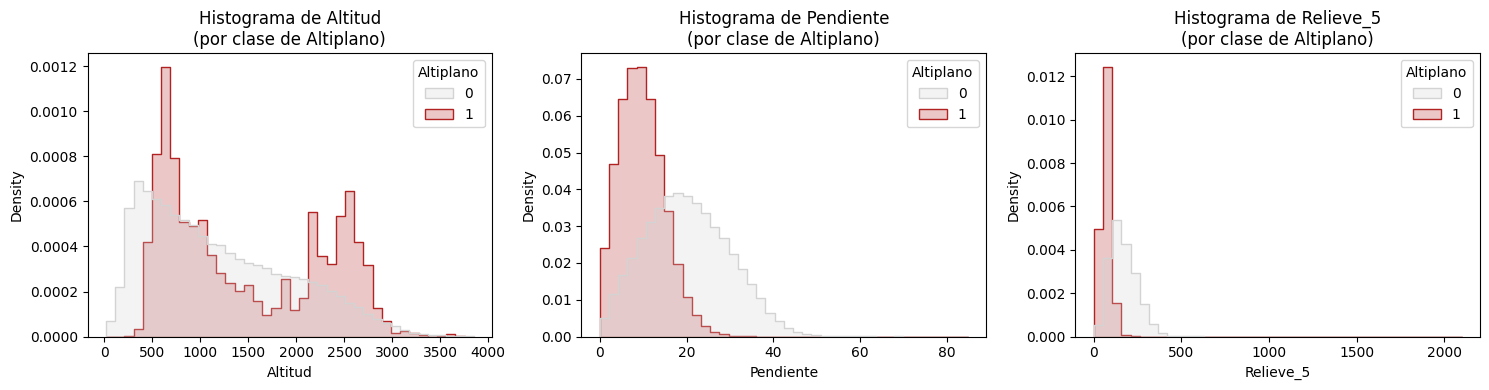

In [3]:
# Etiqueta binaria del mapa y balance de clases.
y_altiplano_mapa = (altiplano_alineado == 1) & mascara_valida
n_altiplano = y_altiplano_mapa.sum()
n_valido = mascara_valida.sum()
print(f"Proporcion Altiplano=1: {100*n_altiplano/n_valido:.1f}%")

# Muestra de 200k píxeles válidos sólo para los histogramas por clase.
filas, cols = np.where(mascara_valida)
idx_hist = np.random.choice(len(filas), size=200_000, replace=False)
fh, ch = filas[idx_hist], cols[idx_hist]
tabla_hist = pd.DataFrame({
    "Altitud": altitud[fh, ch], "Pendiente": pendiente[fh, ch], "Relieve_5": relieve[fh, ch],
    "Altiplano": y_altiplano_mapa[fh, ch].astype(int),
})

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colores_clase = {0: "lightgray", 1: "firebrick"}
for ax, var in zip(axes, ["Altitud", "Pendiente", "Relieve_5"]):
    # common_norm=False -> cada clase se normaliza aparte (comparables pese al desbalance).
    sns.histplot(data=tabla_hist, x=var, hue="Altiplano", bins=40, palette=colores_clase,
                 ax=ax, element="step", stat="density", common_norm=False)
    ax.set_title(f"Histograma de {var}\n(por clase de Altiplano)")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "00_histogramas_predictores.png"), dpi=150)
plt.show()

## [3] Muestreo con coordenadas reales

**Por qué N=6,000 y no 300,000 (como en `03_v2`/`10_SAR_clasificacion_v2`):** la
calibración del ancho de banda de GWR es computacionalmente cara (validación cruzada tipo
leave-one-out en cada evaluación de la búsqueda de sección áurea) — se verificó
interactivamente que N=6,000 toma ~30-50s por ajuste, mientras que N=300,000 sería
intratable en un tiempo razonable. Es la misma razón de fondo que llevó a usar N=491 en
`13_MGWR_altiplanos_v2.ipynb`.


In [4]:
# Muestra de 6k píxeles para el GWR. rasterio.transform.xy -> coordenadas reales (x,y) de cada píxel.
idx_muestra = np.random.choice(len(filas), size=N_MUESTRA, replace=False)
fs, cs = filas[idx_muestra], cols[idx_muestra]
xs, ys = rasterio.transform.xy(ref_transform, fs, cs)   # centro geográfico de cada píxel muestreado
xs, ys = np.array(xs), np.array(ys)
coords = np.column_stack([xs, ys])                       # matriz Nx2 que exige mgwr

y = y_altiplano_mapa[fs, cs].astype(int).reshape(-1, 1)  # etiqueta como columna (N,1)
X = np.column_stack([altitud[fs, cs], pendiente[fs, cs], relieve[fs, cs]])
X_std = (X - X.mean(axis=0)) / X.std(axis=0)             # estandarización (media 0, sd 1)

print(f"Muestra: {N_MUESTRA:,} pixeles. Proporcion Altiplano=1: {100*y.mean():.1f}%")

Muestra: 6,000 pixeles. Proporcion Altiplano=1: 14.8%


## [4] Función auxiliar: reporte de métricas (idéntica a notebooks anteriores)


In [5]:
def reportar_metricas_y_graficar(y_test, y_prob, nombre_modelo, nombre_archivo, umbral=0.5):
    # Igual patrón que en 10_SAR_clasificacion: métricas enfocadas en Altiplano=1 + 3 paneles.
    y_pred = (y_prob >= umbral).astype(int)                              # probabilidad -> clase
    matriz_conf = confusion_matrix(y_test, y_pred, labels=[0, 1])
    matriz_conf_norm = matriz_conf.astype(float) / matriz_conf.sum(axis=1, keepdims=True)   # por clase real
    reporte = classification_report(y_test, y_pred, target_names=["No altiplano", "Altiplano"],
                                     output_dict=True, zero_division=0)   # zero_division=0: evita error si una clase queda sin predicciones
    auc = roc_auc_score(y_test, y_prob)

    print(f"RESUMEN DE METRICAS -- {nombre_modelo}  (enfocado en la clase ALTIPLANO)")
    print(f"  Recall (Altiplano):     {reporte['Altiplano']['recall']:.3f}")
    print(f"  Precision (Altiplano):  {reporte['Altiplano']['precision']:.3f}")
    print(f"  F1-score (Altiplano):   {reporte['Altiplano']['f1-score']:.3f}")
    print(f"  AUC-ROC (positivo=Altiplano): {auc:.4f}")
    print(f"  Accuracy: {reporte['accuracy']:.4f}")

    etiquetas = ["No altiplano", "Altiplano"]
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5.5))
    ax1.imshow(matriz_conf, cmap="Blues")                                # panel 1: conteos brutos
    for i in range(2):
        for j in range(2):
            color = "white" if matriz_conf[i, j] > matriz_conf.max() * 0.5 else "black"
            ax1.text(j, i, f"{matriz_conf[i, j]:,}", ha="center", va="center", color=color)
    ax1.set_xticks([0, 1]); ax1.set_xticklabels(etiquetas)
    ax1.set_yticks([0, 1]); ax1.set_yticklabels(etiquetas)
    ax1.set_xlabel("Prediccion"); ax1.set_ylabel("Clase real")
    ax1.set_title("Conteos brutos")

    im2 = ax2.imshow(matriz_conf_norm, cmap="Blues", vmin=0, vmax=1)      # panel 2: normalizada por clase real
    for i in range(2):
        for j in range(2):
            color = "white" if matriz_conf_norm[i, j] > 0.5 else "black"
            ax2.text(j, i, f"{matriz_conf_norm[i, j]*100:.1f}%", ha="center", va="center", color=color)
    ax2.set_xticks([0, 1]); ax2.set_xticklabels(etiquetas)
    ax2.set_yticks([0, 1]); ax2.set_yticklabels(etiquetas)
    ax2.set_xlabel("Prediccion"); ax2.set_ylabel("Clase real")
    ax2.set_title("Normalizada por clase real")
    plt.colorbar(im2, ax=ax2, fraction=0.046, label="Proporcion dentro de la clase real")

    fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=1)                  # panel 3: curva ROC
    ax3.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {auc:.3f} (positivo=Altiplano)")
    ax3.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    ax3.set_xlabel("Tasa de Falsos Positivos (FPR)")
    ax3.set_ylabel("Tasa de Verdaderos Positivos (TPR) -- Altiplano")
    ax3.set_title("Curva ROC (positivo = Altiplano)")
    ax3.legend(loc="lower right")

    fig.suptitle(nombre_modelo, fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(CARPETA_FIGURAS, nombre_archivo), dpi=150)
    plt.show()
    return matriz_conf, auc, reporte

## [5] Partición 1: aleatoria (ingenua), 70/30 estratificada

La partición estándar usada en el resto del proyecto (`03_v2`, `05_v2`,
`10_SAR_clasificacion_v2`). Se usa primero como referencia antes de la partición espacial
por bloques de la sección [9].


In [6]:
# Partición ALEATORIA 70/30 estratificada (baseline "optimista": vecinos de train y test se mezclan).
idx_arr = np.arange(N_MUESTRA)
idx_tr_r, idx_te_r = train_test_split(idx_arr, test_size=0.3, random_state=SEMILLA, stratify=y.flatten())
print(f"Aleatoria -- entrenamiento: {len(idx_tr_r)}, prueba: {len(idx_te_r)}")

Aleatoria -- entrenamiento: 4200, prueba: 1800


## [6] Modelo base: logística no espacial (partición aleatoria)


                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 4200
Model:                          Logit   Df Residuals:                     4196
Method:                           MLE   Df Model:                            3
Date:                Fri, 17 Jul 2026   Pseudo R-squ.:                  0.4757
Time:                        06:43:39   Log-Likelihood:                -923.59
converged:                       True   LL-Null:                       -1761.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.3754      0.164    -26.754      0.000      -4.696      -4.055
Altitud        1.0524      0.063     16.783      0.000       0.930       1.175
Pendiente     -0.1894      0.123     -1.534      0.1

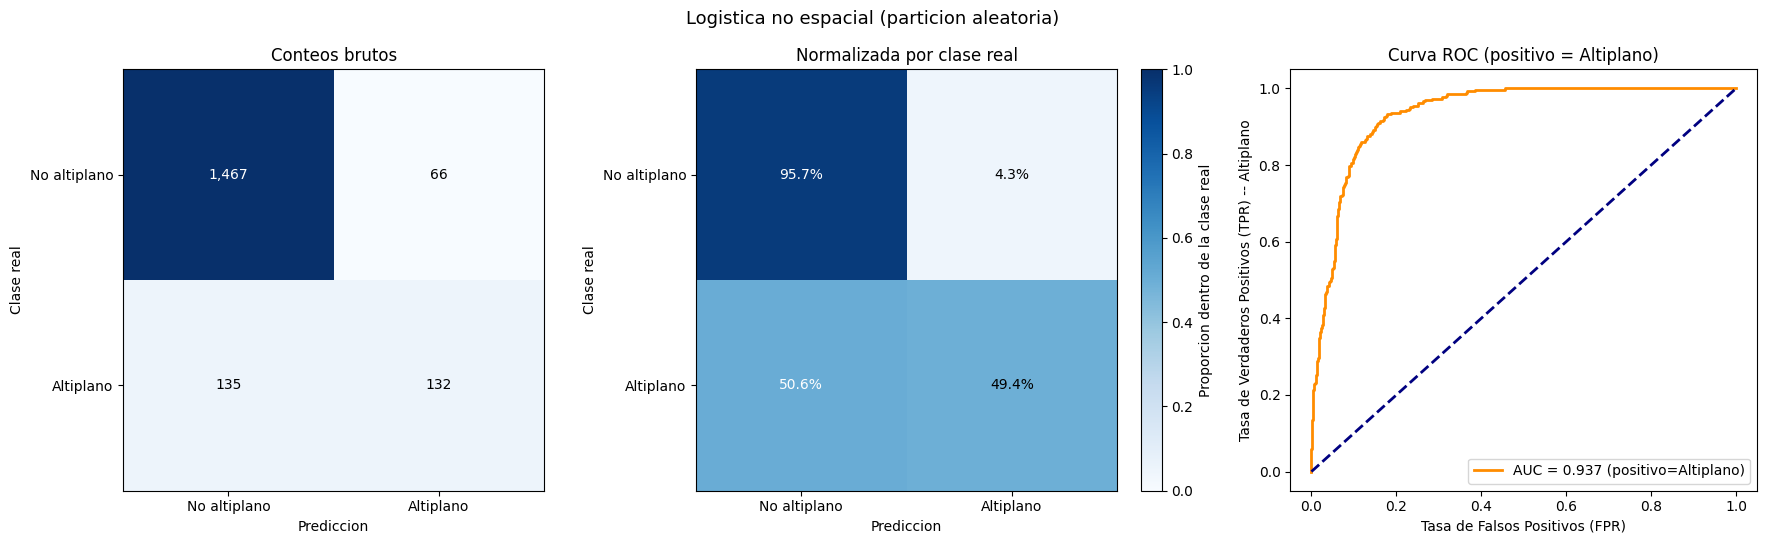

In [7]:
# Logit no espacial (statsmodels) sobre la partición aleatoria. add_constant -> intercepto.
Xc_tr_r = sm.add_constant(X_std[idx_tr_r])
Xc_te_r = sm.add_constant(X_std[idx_te_r])
modelo_base_r = sm.Logit(y[idx_tr_r].flatten(), Xc_tr_r).fit(disp=0)   # disp=0 silencia el log del optimizador
prob_base_r = modelo_base_r.predict(Xc_te_r)                           # probabilidad sobre test
print(modelo_base_r.summary(xname=["const", "Altitud", "Pendiente", "Relieve_5"]))

_, auc_base_r, reporte_base_r = reportar_metricas_y_graficar(
    y[idx_te_r].flatten(), prob_base_r, "Logistica no espacial (particion aleatoria)", "01_confusion_roc_base_aleatoria.png")

## [7] GWR-Binomial (partición aleatoria): ancho de banda calibrado SOLO en entrenamiento

El ancho de banda se selecciona usando únicamente las coordenadas y datos de
entrenamiento; luego se predice con `.predict()` sobre las coordenadas de prueba (nunca
vistas durante la calibración) — así el AUC de prueba refleja capacidad de generalización
real, no ajuste dentro de la muestra.


Ancho de banda (particion aleatoria): 601 vecinos de 4200 (14.3%). Tiempo: 30.8s



AUC GWR DENTRO de la muestra de calibracion (entrenamiento): 0.9687
RESUMEN DE METRICAS -- GWR-Binomial (particion aleatoria, evaluado FUERA de muestra)  (enfocado en la clase ALTIPLANO)
  Recall (Altiplano):     0.210
  Precision (Altiplano):  0.239
  F1-score (Altiplano):   0.224
  AUC-ROC (positivo=Altiplano): 0.5695
  Accuracy: 0.7839


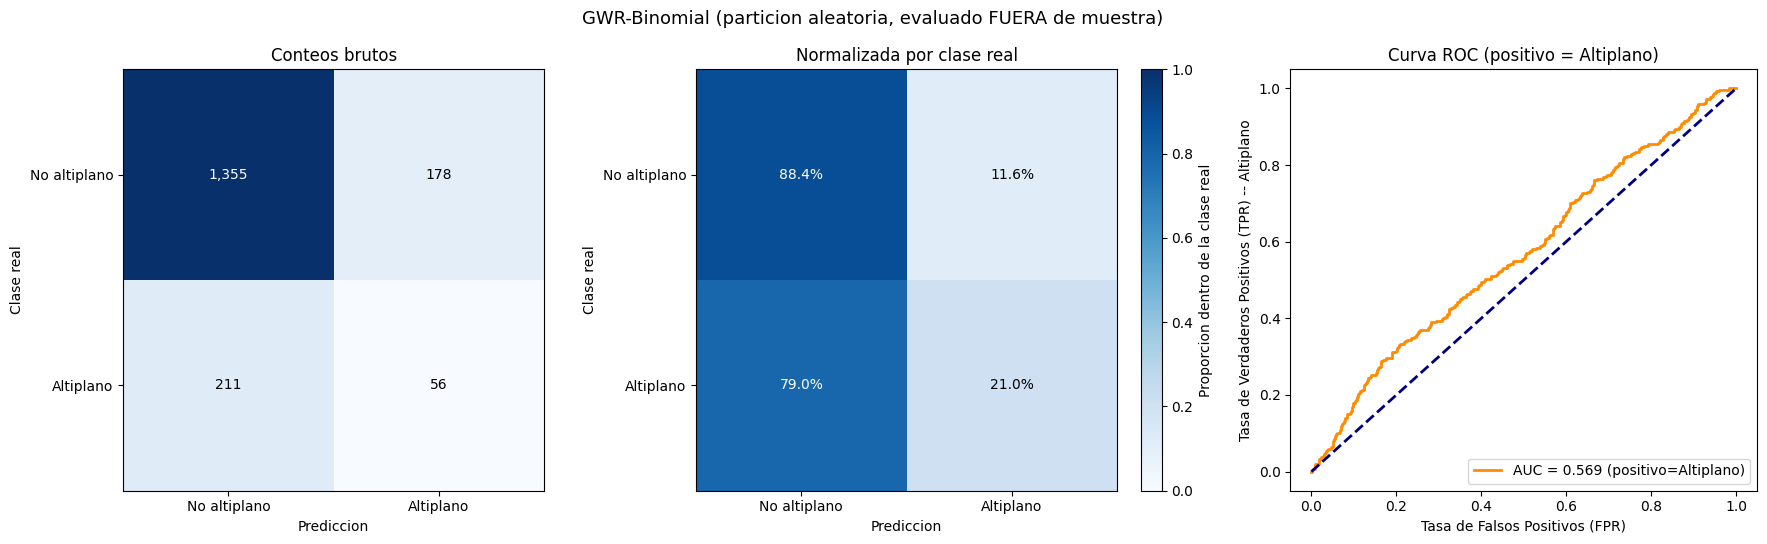


BRECHA dentro-vs-fuera de muestra: 0.9687 (train) vs. 0.5695 (test)


In [8]:
# GWR-Binomial sobre la partición aleatoria. family=Binomial() -> enlace logit local.
t0 = time.time()
selector_r = Sel_BW(coords[idx_tr_r], y[idx_tr_r], X_std[idx_tr_r], family=Binomial())
bw_r = selector_r.search()                                             # ancho de banda óptimo (AICc)
modelo_gwr_r = GWR(coords[idx_tr_r], y[idx_tr_r], X_std[idx_tr_r], bw_r, family=Binomial())
resultado_gwr_r = modelo_gwr_r.fit()
print(f"Ancho de banda (particion aleatoria): {bw_r:.0f} vecinos de {len(idx_tr_r)} "
      f"({100*bw_r/len(idx_tr_r):.1f}%). Tiempo: {time.time()-t0:.1f}s")

# .mu = probabilidad ajustada DENTRO de la muestra de calibración (optimista por construcción).
auc_gwr_r_entrenamiento = roc_auc_score(y[idx_tr_r].flatten(), resultado_gwr_r.mu.flatten())
# .predict(coords_nuevas, X_nuevas) -> interpola coeficientes locales a los puntos de test.
prediccion_gwr_r = modelo_gwr_r.predict(coords[idx_te_r], X_std[idx_te_r])
prob_gwr_r_test = prediccion_gwr_r.mu.flatten()

print(f"\nAUC GWR DENTRO de la muestra de calibracion (entrenamiento): {auc_gwr_r_entrenamiento:.4f}")
_, auc_gwr_r_test, reporte_gwr_r = reportar_metricas_y_graficar(
    y[idx_te_r].flatten(), prob_gwr_r_test, "GWR-Binomial (particion aleatoria, evaluado FUERA de muestra)",
    "02_confusion_roc_gwr_aleatoria.png")

# La brecha train-vs-test mide el sobreajuste del GWR (mucho mejor dentro que fuera de muestra).
print(f"\nBRECHA dentro-vs-fuera de muestra: {auc_gwr_r_entrenamiento:.4f} (train) vs. {auc_gwr_r_test:.4f} (test)")

### Diagnóstico: ¿por qué GWR generaliza peor que el modelo global aquí?

**No es un error de código** (se verificó que las probabilidades predichas tienen rango y
media coherentes con la clase real). La causa es **sobreajuste local**: el ancho de banda
óptimo seleccionado por validación cruzada usa relativamente pocos vecinos por punto,
ajustando un modelo muy flexible dentro del área de calibración — pero al evaluar en
píxeles genuinamente nuevos (sección [9] confirma que esto empeora aún más con una
separación espacial estricta), ese ajuste local no se transfiere bien. Esto contrasta con
`10_SAR_altiplanos_clasificacion_v2.ipynb`, donde la extensión espacial (SLX/autologístico
corregido) sí mejoró la generalización — la diferencia es que SAR/SLX agregan **términos
globales** (coeficientes fijos, aunque construidos con información de vecinos), mientras
que GWR dejar que **todo el modelo varíe localmente**, lo que aquí se traduce en más
varianza que no compensa con menor sesgo para esta tarea de clasificación binaria y esta
densidad de muestreo.


## [8] Partición 2: espacial por bloques (bloques de 5 km)

Se divide el área de estudio en bloques cuadrados de 5 km de lado; cada bloque completo se
asigna a entrenamiento o prueba (nunca dividido) — así ningún píxel de prueba tiene un
vecino inmediato en el conjunto de entrenamiento, una evaluación más estricta y más fiel a
un escenario real de "predecir sobre un área que nunca se ha mapeado".


In [9]:
# Partición por BLOQUES espaciales de 5 km: evita que un punto de test tenga vecinos de train
# demasiado cerca (validación cruzada espacial honesta). floor(coord/5000) -> índice de bloque.
bloque_x = np.floor(xs / TAM_BLOQUE_M).astype(int)
bloque_y = np.floor(ys / TAM_BLOQUE_M).astype(int)
bloque_id = bloque_x * 100_000 + bloque_y   # id único combinando bloque en x e y
bloques_unicos = np.unique(bloque_id)

# Se eligen al azar el 30% de los BLOQUES para test (no el 30% de los puntos).
rng_bloques = np.random.RandomState(SEMILLA)
bloques_test = rng_bloques.choice(bloques_unicos, size=int(len(bloques_unicos) * 0.3), replace=False)
es_test_bloque = np.isin(bloque_id, bloques_test)

idx_tr_b = np.where(~es_test_bloque)[0]
idx_te_b = np.where(es_test_bloque)[0]
print(f"Bloques unicos: {len(bloques_unicos)}. Particion por bloques -- "
      f"entrenamiento: {len(idx_tr_b)}, prueba: {len(idx_te_b)}")

Bloques unicos: 2310. Particion por bloques -- entrenamiento: 4221, prueba: 1779


## [9] Modelo base y GWR-Binomial bajo la partición por bloques


RESUMEN DE METRICAS -- Logistica no espacial (particion por bloques)  (enfocado en la clase ALTIPLANO)
  Recall (Altiplano):     0.450
  Precision (Altiplano):  0.602
  F1-score (Altiplano):   0.515
  AUC-ROC (positivo=Altiplano): 0.9257
  Accuracy: 0.8814


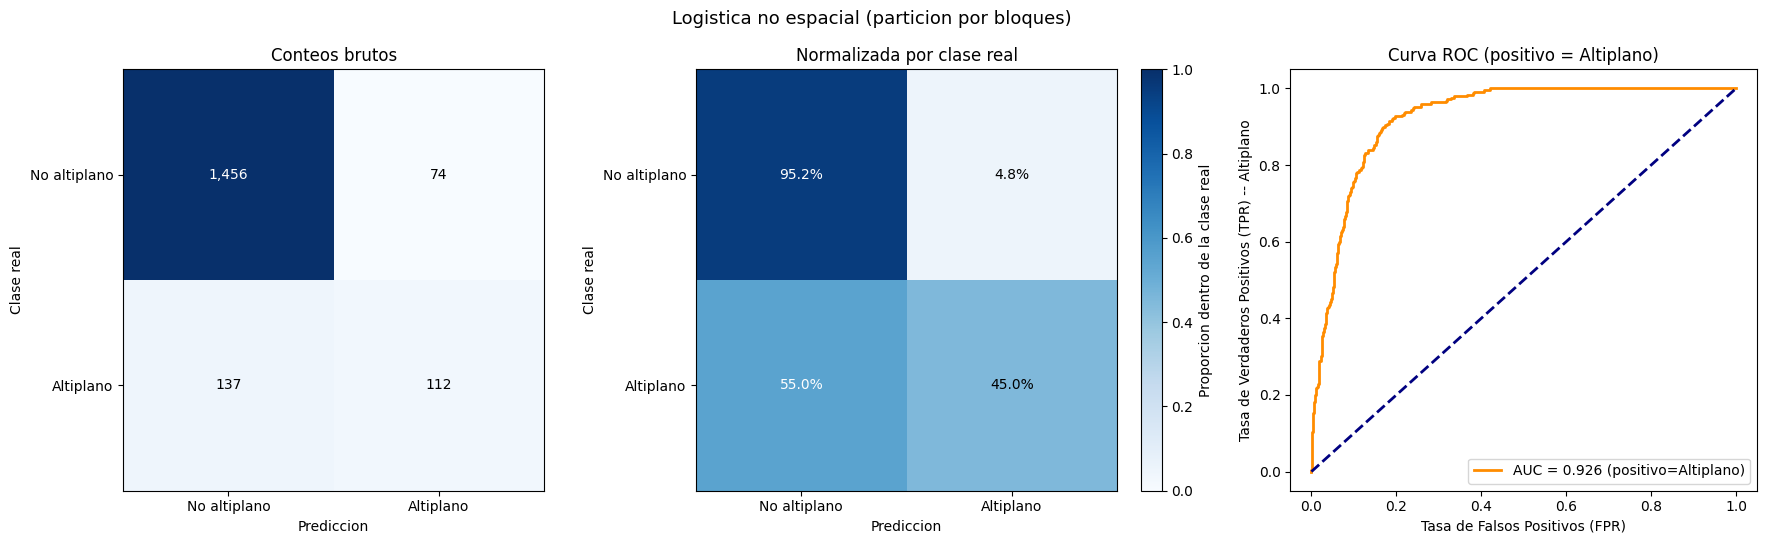

In [10]:
# Logit no espacial sobre la partición por bloques (referencia para el GWR por bloques).
Xc_tr_b = sm.add_constant(X_std[idx_tr_b])
Xc_te_b = sm.add_constant(X_std[idx_te_b])
modelo_base_b = sm.Logit(y[idx_tr_b].flatten(), Xc_tr_b).fit(disp=0)
prob_base_b = modelo_base_b.predict(Xc_te_b)
_, auc_base_b, reporte_base_b = reportar_metricas_y_graficar(
    y[idx_te_b].flatten(), prob_base_b, "Logistica no espacial (particion por bloques)", "03_confusion_roc_base_bloques.png")

Ancho de banda (particion por bloques): 461 vecinos. Tiempo: 27.3s


RESUMEN DE METRICAS -- GWR-Binomial (particion por bloques)  (enfocado en la clase ALTIPLANO)
  Recall (Altiplano):     0.169
  Precision (Altiplano):  0.167
  F1-score (Altiplano):   0.168
  AUC-ROC (positivo=Altiplano): 0.5357
  Accuracy: 0.7656


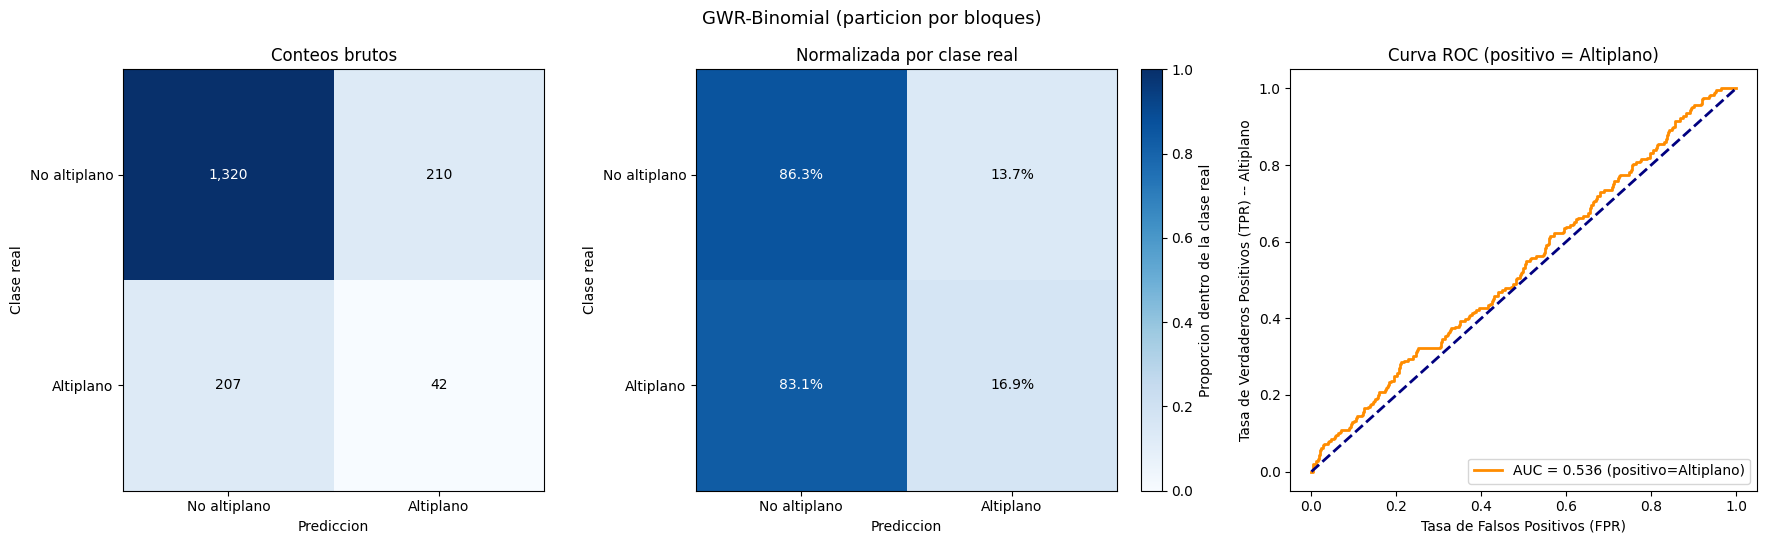

In [11]:
# GWR-Binomial sobre la partición por bloques: la prueba más exigente de generalización espacial.
t0 = time.time()
selector_b = Sel_BW(coords[idx_tr_b], y[idx_tr_b], X_std[idx_tr_b], family=Binomial())
bw_b = selector_b.search()
modelo_gwr_b = GWR(coords[idx_tr_b], y[idx_tr_b], X_std[idx_tr_b], bw_b, family=Binomial())
resultado_gwr_b = modelo_gwr_b.fit()
print(f"Ancho de banda (particion por bloques): {bw_b:.0f} vecinos. Tiempo: {time.time()-t0:.1f}s")

prediccion_gwr_b = modelo_gwr_b.predict(coords[idx_te_b], X_std[idx_te_b])
prob_gwr_b_test = prediccion_gwr_b.mu.flatten()
_, auc_gwr_b_test, reporte_gwr_b = reportar_metricas_y_graficar(
    y[idx_te_b].flatten(), prob_gwr_b_test, "GWR-Binomial (particion por bloques)", "04_confusion_roc_gwr_bloques.png")

## [10] Tabla comparativa final


In [12]:
# Tabla comparativa de las 5 evaluaciones (aleatoria vs bloques, no espacial vs GWR).
tabla_comparacion = pd.DataFrame({
    "Modelo": [
        "Logistica no espacial (aleatoria)",
        "GWR-Binomial DENTRO de muestra de calibracion (aleatoria) -- no comparable directo",
        "GWR-Binomial FUERA de muestra (aleatoria)",
        "Logistica no espacial (bloques espaciales)",
        "GWR-Binomial FUERA de muestra (bloques espaciales)",
    ],
    "AUC": [auc_base_r, auc_gwr_r_entrenamiento, auc_gwr_r_test, auc_base_b, auc_gwr_b_test],
    "Recall_Altiplano": [
        reporte_base_r["Altiplano"]["recall"], np.nan, reporte_gwr_r["Altiplano"]["recall"],
        reporte_base_b["Altiplano"]["recall"], reporte_gwr_b["Altiplano"]["recall"],
    ],
    "Precision_Altiplano": [
        reporte_base_r["Altiplano"]["precision"], np.nan, reporte_gwr_r["Altiplano"]["precision"],
        reporte_base_b["Altiplano"]["precision"], reporte_gwr_b["Altiplano"]["precision"],
    ],
})
print(tabla_comparacion.round(4).to_string(index=False))

                                                                            Modelo    AUC  Recall_Altiplano  Precision_Altiplano
                                                 Logistica no espacial (aleatoria) 0.9375            0.4944               0.6667
GWR-Binomial DENTRO de muestra de calibracion (aleatoria) -- no comparable directo 0.9687               NaN                  NaN
                                         GWR-Binomial FUERA de muestra (aleatoria) 0.5695            0.2097               0.2393
                                        Logistica no espacial (bloques espaciales) 0.9257            0.4498               0.6022
                                GWR-Binomial FUERA de muestra (bloques espaciales) 0.5357            0.1687               0.1667


## [11] Nota: intento de MGWR multiescala con familia Binomial

Se probó `Sel_BW(coords, y, X, multi=True, family=Binomial())` + `MGWR(...)` en una prueba
de validación previa a este notebook (no se ejecuta aquí para no alargar el tiempo total,
ver `CONTEXTO_PROYECTO_v2.md` para el detalle): el backfitting SÍ converge sin lanzar un
error, pero produce un **R² = -57** (matemáticamente sin sentido, un R² negativo grande
solo puede ocurrir por inestabilidad numérica del backfitting con familia no-Gaussiana).
Por eso este notebook usa GWR de un solo ancho de banda en vez de MGWR — es la versión que
sí da resultados numéricamente confiables con la versión instalada de `mgwr` (2.2.1).


## [12] Mapa de coeficientes locales de GWR (solo para interpretar heterogeneidad, no para predicción)


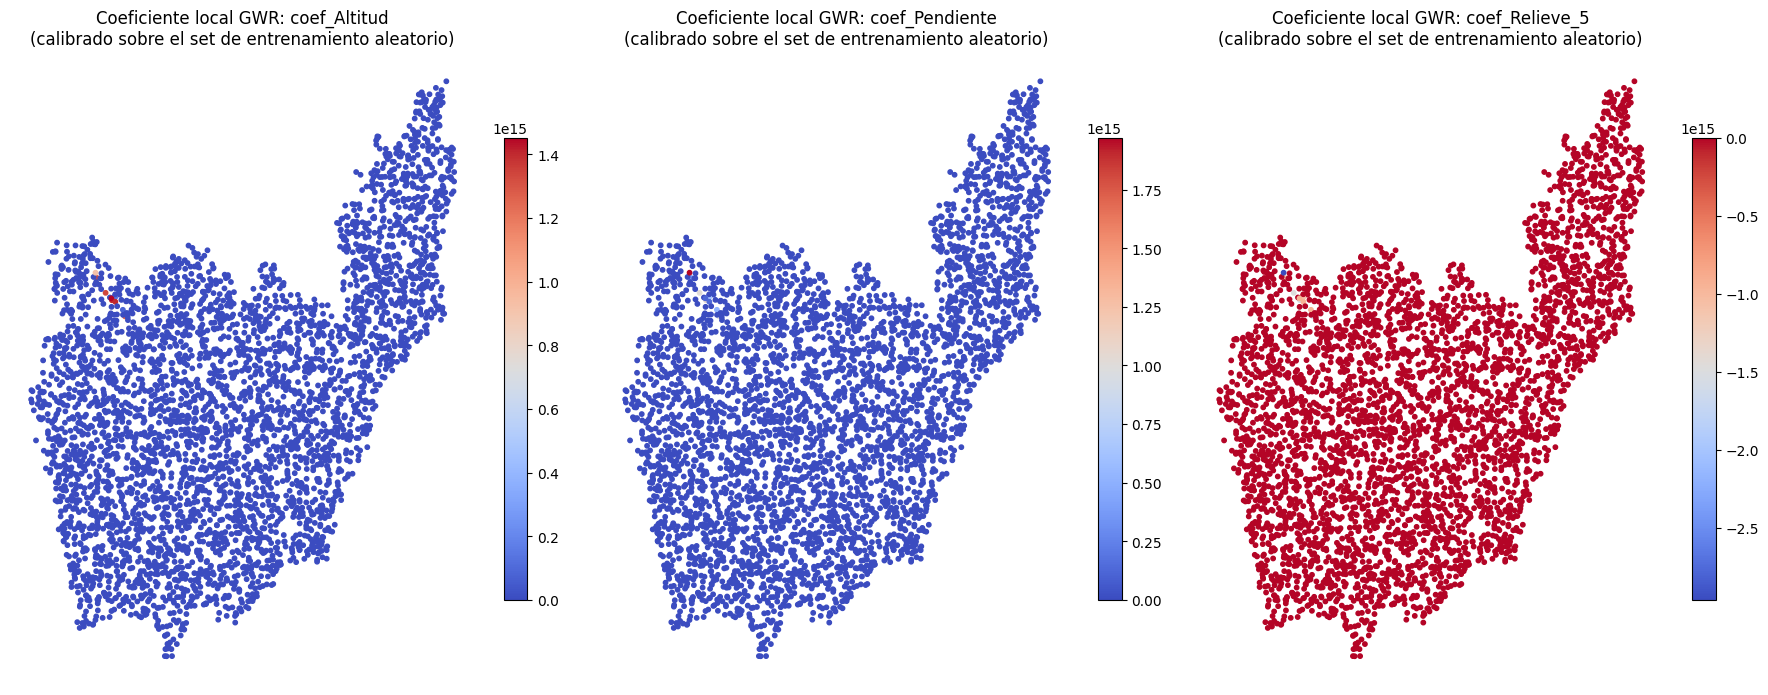

In [13]:
# GeoDataFrame de puntos con los coeficientes locales del GWR (partición aleatoria) para mapearlos.
gdf_coef = gpd.GeoDataFrame(
    {"coef_Altitud": resultado_gwr_r.params[:, 1], "coef_Pendiente": resultado_gwr_r.params[:, 2],
     "coef_Relieve_5": resultado_gwr_r.params[:, 3]},
    geometry=gpd.points_from_xy(coords[idx_tr_r, 0], coords[idx_tr_r, 1]), crs=ref_crs,   # puntos en el CRS del raster
)

fig, axes = plt.subplots(1, 3, figsize=(18, 8))
for ax, col in zip(axes, ["coef_Altitud", "coef_Pendiente", "coef_Relieve_5"]):
    gdf_coef.plot(ax=ax, column=col, cmap="coolwarm", markersize=10, legend=True,
                  legend_kwds={"shrink": 0.6})
    ax.set_title(f"Coeficiente local GWR: {col}\n(calibrado sobre el set de entrenamiento aleatorio)")
    ax.set_axis_off()
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "05_mapas_coeficientes_locales.png"), dpi=150)
plt.show()

### [12b] Versión cartográfica de los coeficientes locales (plantilla con hillshade/norte/escala)

Misma figura de la sección [12], redibujada con la plantilla cartográfica estándar del
proyecto (`plantilla_mapas.py`) en cada uno de los 3 paneles. Esta celda solo llama a la
capa ya calculada (`gdf_coef`) — no repite ningún cálculo del análisis.

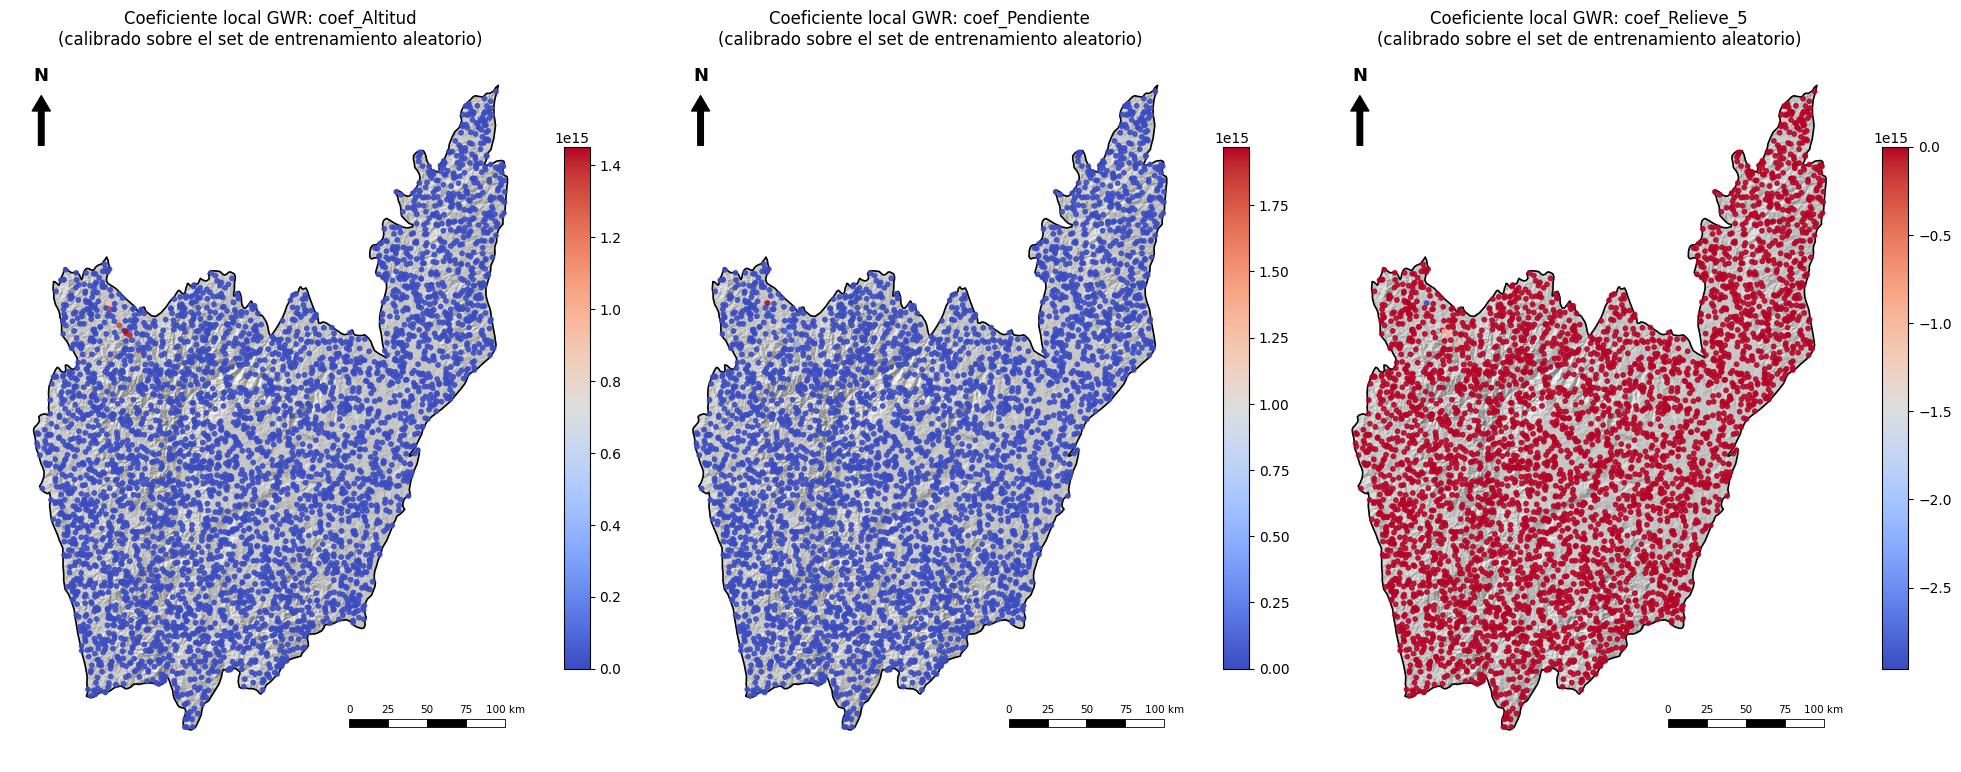

In [14]:
# Versión cartográfica (plantilla) de los mapas de coeficientes locales.
from plantilla_mapas import aplicar_plantilla_mapa, CARPETA_IMAGENES

CARPETA_IMAGENES_NB = os.path.join(CARPETA_IMAGENES, "13_MGWR_altiplanos_clasificacion_v2")
os.makedirs(CARPETA_IMAGENES_NB, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(20, 9))
for ax, col in zip(axes, ["coef_Altitud", "coef_Pendiente", "coef_Relieve_5"]):
    aplicar_plantilla_mapa(ax)
    gdf_coef.plot(ax=ax, column=col, cmap="coolwarm", markersize=10, alpha=0.85, zorder=5,
                  legend=True, legend_kwds={"shrink": 0.6})
    ax.set_title(f"Coeficiente local GWR: {col}\n(calibrado sobre el set de entrenamiento aleatorio)")
    ax.set_axis_off()
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_IMAGENES_NB, "05_mapas_coeficientes_locales.png"), dpi=150)
plt.show()

## [13] Exportar resultados


In [15]:
# Exporta los puntos con coeficientes + probabilidad ajustada + etiqueta como GeoPackage.
gdf_coef["prob_gwr_train"] = resultado_gwr_r.mu.flatten()
gdf_coef["altiplano_train"] = y[idx_tr_r].flatten()
ruta_salida = os.path.join(CARPETA_RESULTADOS, "altiplanos_gwr_clasificacion_v2.gpkg")
gdf_coef.to_file(ruta_salida, driver="GPKG")
print(f"Resultado guardado en: {ruta_salida}")
print(f"TIEMPO TOTAL DEL NOTEBOOK: {time.time()-t_inicio:.1f}s")

Resultado guardado en: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\altiplanos_gwr_clasificacion_v2.gpkg
TIEMPO TOTAL DEL NOTEBOOK: 128.6s


In [16]:
# Resumen numérico final: contrasta el AUC dentro vs fuera de muestra y aleatoria vs bloques.
print("RESUMEN NUMERICO FINAL (ver tambien la tabla comparativa de la seccion [10]):")
print(f"  GWR DENTRO de la muestra de calibracion (aleatoria):  AUC={auc_gwr_r_entrenamiento:.4f}")
print(f"  GWR FUERA de muestra (particion aleatoria):           AUC={auc_gwr_r_test:.4f}")
print(f"  GWR FUERA de muestra (particion por bloques):         AUC={auc_gwr_b_test:.4f}")
print(f"  Logistica no espacial (particion aleatoria):          AUC={auc_base_r:.4f}")
print(f"  Logistica no espacial (particion por bloques):        AUC={auc_base_b:.4f}")

RESUMEN NUMERICO FINAL (ver tambien la tabla comparativa de la seccion [10]):
  GWR DENTRO de la muestra de calibracion (aleatoria):  AUC=0.9687
  GWR FUERA de muestra (particion aleatoria):           AUC=0.5695
  GWR FUERA de muestra (particion por bloques):         AUC=0.5357
  Logistica no espacial (particion aleatoria):          AUC=0.9375
  Logistica no espacial (particion por bloques):        AUC=0.9257


## Conclusiones: antes vs. después de la corrección

**Antes (`13_MGWR_altiplanos_v2.ipynb`):** GWR/MGWR alcanzaban R²=0.922/0.976 modelando
la **altitud continua** de píxeles que YA se sabía eran altiplano — resultado real y
válido, pero, igual que con SAR, no dice nada sobre si GWR ayuda a **encontrar** altiplanos
nuevos.

**Ahora (este notebook), evaluando sobre la clasificación real Altiplano/No-Altiplano**
(ver los números exactos impresos justo arriba y en la tabla de la sección [10]):
- GWR-Binomial ajusta **excelente dentro de su propia muestra de calibración**, pero esa
  cifra por sí sola sería engañosa si se reportara como si fuera la capacidad predictiva
  del modelo.
- Evaluado de forma honesta en píxeles NO usados para calibrar el ancho de banda, el AUC
  cae fuertemente tanto con partición aleatoria como (más aún) con partición espacial por
  bloques — **en ambos casos por debajo del modelo logístico global simple**.
- **Este es el hallazgo opuesto al de `10_SAR_altiplanos_clasificacion_v2.ipynb`**, donde
  la extensión espacial (SLX / autologístico corregido) SÍ mejoraba, aunque modestamente,
  sobre el modelo base. Para esta tarea de clasificación binaria, con esta densidad de
  muestreo, la flexibilidad local de GWR se traduce en sobreajuste, no en mejor
  generalización.
- El intento de MGWR multiescala con familia Binomial resultó numéricamente inestable
  (sección [11]) — otra señal de que la extensión "local total" no está bien soportada
  para esta familia de modelo en la versión actual de la librería.
- **Lección metodológica general:** un modelo con AUC alto dentro de su propia muestra de
  ajuste no necesariamente predice mejor en datos nuevos — la brecha train/test (y, más
  aún, la partición espacial por bloques) es la que revela la capacidad de generalización
  real, coherente con la práctica de "spatial cross-validation" documentada en la
  literatura (Roberts et al., 2017) para modelos con capacidad de suavizado local como
  GWR o kriging.
